#### Data Preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [5]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [6]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [7]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [8]:
df.churn

0        no
1        no
2       yes
3        no
4       yes
       ... 
7038     no
7039     no
7040     no
7041    yes
7042     no
Name: churn, Length: 7043, dtype: str

In [9]:
df.churn = (df.churn == 'yes').astype(int)

In [10]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

#### Setting up the validation framework

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [13]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [14]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [15]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [16]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [17]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

#### EDA

In [18]:
df_full_train = df_full_train.reset_index(drop=True)

In [19]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [20]:
df_full_train.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [21]:
print(df_full_train.churn.value_counts())
print(df_full_train.churn.value_counts(normalize=True))

churn
0    4113
1    1521
Name: count, dtype: int64
churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64


In [22]:
print(df_full_train.dtypes)

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object


In [23]:
global_churn_rate = df_full_train.churn.mean()

In [24]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [25]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [26]:
categorical = list(set(df_full_train.columns) - set(numerical) - set(['churn']))

In [27]:
categorical

['customerid',
 'paperlessbilling',
 'onlinebackup',
 'gender',
 'streamingtv',
 'streamingmovies',
 'partner',
 'internetservice',
 'dependents',
 'onlinesecurity',
 'seniorcitizen',
 'techsupport',
 'deviceprotection',
 'phoneservice',
 'multiplelines',
 'paymentmethod',
 'contract']

In [28]:
df_full_train[categorical].nunique().sort_values()

paperlessbilling       2
gender                 2
partner                2
dependents             2
seniorcitizen          2
phoneservice           2
streamingmovies        3
onlinebackup           3
techsupport            3
internetservice        3
streamingtv            3
onlinesecurity         3
multiplelines          3
deviceprotection       3
contract               3
paymentmethod          4
customerid          5634
dtype: int64

In [29]:
len(df_full_train)

5634

#### Feature importance: Churn rate and risk ratio

Churn rate

In [30]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,yes,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55
2,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65
3,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,no,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.10
4,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.50


In [31]:
df_full_train[df_full_train.gender == 'female'].churn.mean()

np.float64(0.27682403433476394)

In [32]:
df_full_train[df_full_train.gender == 'male'].churn.mean()

np.float64(0.2632135306553911)

In [33]:
df_full_train.gender.unique().tolist()

['male', 'female']

In [34]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()

In [35]:
print(churn_partner, churn_no_partner)

0.20503330866025166 0.3298090040927694


In [36]:
churn_rates = {}
for c in categorical:
    if c == 'customerid':
        continue
    values = df_full_train[c].unique().tolist()
    for v in values:
        key = f'churn_rate_{c}_{v}'
        churn_rates[key] = df_full_train[df_full_train[c] == v].churn.mean()    

In [37]:
churn_rates

{'churn_rate_paperlessbilling_no': np.float64(0.17207090358841332),
 'churn_rate_paperlessbilling_yes': np.float64(0.3381511592893707),
 'churn_rate_onlinebackup_no_internet_service': np.float64(0.07780507780507781),
 'churn_rate_onlinebackup_yes': np.float64(0.21723237597911227),
 'churn_rate_onlinebackup_no': np.float64(0.4043234587670136),
 'churn_rate_gender_male': np.float64(0.2632135306553911),
 'churn_rate_gender_female': np.float64(0.27682403433476394),
 'churn_rate_streamingtv_no_internet_service': np.float64(0.07780507780507781),
 'churn_rate_streamingtv_no': np.float64(0.3428317008014248),
 'churn_rate_streamingtv_yes': np.float64(0.3027226580526073),
 'churn_rate_streamingmovies_no_internet_service': np.float64(0.07780507780507781),
 'churn_rate_streamingmovies_yes': np.float64(0.30727272727272725),
 'churn_rate_streamingmovies_no': np.float64(0.33890646181653866),
 'churn_rate_partner_yes': np.float64(0.20503330866025166),
 'churn_rate_partner_no': np.float64(0.32980900409

In [38]:
churn_rates = dict(sorted(churn_rates.items(), key=lambda x: x[1], reverse=True))

In [39]:
churn_rates

{'churn_rate_paymentmethod_electronic_check': np.float64(0.45589012150026414),
 'churn_rate_contract_month-to-month': np.float64(0.43170103092783507),
 'churn_rate_internetservice_fiber_optic': np.float64(0.42517144009681324),
 'churn_rate_onlinesecurity_no': np.float64(0.42092109960728313),
 'churn_rate_techsupport_no': np.float64(0.41891405969075873),
 'churn_rate_seniorcitizen_1': np.float64(0.4133771929824561),
 'churn_rate_onlinebackup_no': np.float64(0.4043234587670136),
 'churn_rate_deviceprotection_no': np.float64(0.3958754549130611),
 'churn_rate_streamingtv_no': np.float64(0.3428317008014248),
 'churn_rate_streamingmovies_no': np.float64(0.33890646181653866),
 'churn_rate_paperlessbilling_yes': np.float64(0.3381511592893707),
 'churn_rate_partner_no': np.float64(0.3298090040927694),
 'churn_rate_dependents_no': np.float64(0.3137600806451613),
 'churn_rate_streamingmovies_yes': np.float64(0.30727272727272725),
 'churn_rate_streamingtv_yes': np.float64(0.3027226580526073),
 'ch

In [40]:
above_global = {
    k: v
    for k, v in churn_rates.items()
    if v > global_churn_rate
}

In [41]:
above_global

{'churn_rate_paymentmethod_electronic_check': np.float64(0.45589012150026414),
 'churn_rate_contract_month-to-month': np.float64(0.43170103092783507),
 'churn_rate_internetservice_fiber_optic': np.float64(0.42517144009681324),
 'churn_rate_onlinesecurity_no': np.float64(0.42092109960728313),
 'churn_rate_techsupport_no': np.float64(0.41891405969075873),
 'churn_rate_seniorcitizen_1': np.float64(0.4133771929824561),
 'churn_rate_onlinebackup_no': np.float64(0.4043234587670136),
 'churn_rate_deviceprotection_no': np.float64(0.3958754549130611),
 'churn_rate_streamingtv_no': np.float64(0.3428317008014248),
 'churn_rate_streamingmovies_no': np.float64(0.33890646181653866),
 'churn_rate_paperlessbilling_yes': np.float64(0.3381511592893707),
 'churn_rate_partner_no': np.float64(0.3298090040927694),
 'churn_rate_dependents_no': np.float64(0.3137600806451613),
 'churn_rate_streamingmovies_yes': np.float64(0.30727272727272725),
 'churn_rate_streamingtv_yes': np.float64(0.3027226580526073),
 'ch

Risk

In [42]:
from IPython.display import display

In [43]:
for c in categorical:
    if c == 'customerid':
        continue
    print(c)
    df_group  = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    display(df_group)
    print()
    print()

paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660




gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328




streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201




dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651




onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390




deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480




phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412




multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121




contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730


#### Feature importance: Mutual information

In [44]:
from sklearn.metrics import mutual_info_score

In [45]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [46]:
mutual_info_score(df_full_train.gender, df_full_train.contract)

7.35465609829622e-05

In [47]:
for c in categorical:
    if c == 'customerid':
        continue
    mi = mutual_info_score(df_full_train.churn, df_full_train[c])
    print(c, mi)

paperlessbilling 0.01758882715925275
onlinebackup 0.0469234640537918
gender 0.0001174846211139946
streamingtv 0.03185333110086085
streamingmovies 0.03158089669519908
partner 0.009967689095399745
internetservice 0.055867945893496467
dependents 0.012345815445534689
onlinesecurity 0.06308524972985574
seniorcitizen 0.009410216144208144
techsupport 0.06103245991777444
deviceprotection 0.04345286925268559
phoneservice 0.00022871269738296285
multiplelines 0.0008574478744731856
paymentmethod 0.043210027531582915
contract 0.0983203874041556


In [48]:
def mutual_info_churn_score(series):
    return mutual_info_score(df_full_train.churn, series) if series.name != 'customerid' else 0

In [49]:
mi = df_full_train[categorical].apply(mutual_info_churn_score).sort_values(ascending=False)

In [50]:
mi.drop('customerid', inplace=True)

In [51]:
mi

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

#### Feature importance: Correlation

In [52]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [53]:
df_full_train[df_full_train.tenure <=2].churn.mean()

np.float64(0.5953420669577875)

In [54]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [55]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [56]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [57]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 40)].churn.mean()

np.float64(0.13746065057712487)

In [58]:
df_full_train[df_full_train.monthlycharges > 40].churn.mean()

np.float64(0.32323232323232326)

#### One-hot encoding 

In [59]:
from sklearn.feature_extraction import DictVectorizer

In [60]:
dicts = df_train[['gender', 'contract']].iloc[:100].to_dict(orient='records')

In [61]:
dv = DictVectorizer(sparse=False)

In [62]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [63]:
dv.transform(dicts)

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

In [64]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [65]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dicts = [{k: v for k, v in d.items() if k != 'customerid'} for d in train_dicts]

In [66]:
train_dicts[0]

{'paperlessbilling': 'yes',
 'onlinebackup': 'yes',
 'gender': 'female',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'partner': 'yes',
 'internetservice': 'fiber_optic',
 'dependents': 'yes',
 'onlinesecurity': 'yes',
 'seniorcitizen': 0,
 'techsupport': 'yes',
 'deviceprotection': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'paymentmethod': 'electronic_check',
 'contract': 'two_year',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [67]:
dv = DictVectorizer(sparse=False)

In [68]:
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [69]:
dv.transform(train_dicts)

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [70]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [71]:
list(dv.transform(train_dicts[:5])[0])

[np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(115.5),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(72.0),
 np.float64(8425.15)]

In [72]:
X_train = dv.fit_transform(train_dicts)

In [73]:
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [74]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
val_dicts = [{k: v for k, v in d.items() if k != 'customerid'} for d in val_dicts]

In [75]:
X_val = dv.transform(val_dicts)

In [76]:
list(X_train[0])

[np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(115.5),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(72.0),
 np.float64(8425.15)]

#### Logistics regression

In [77]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [78]:
z = np.linspace(-5, 5, 51)

In [79]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

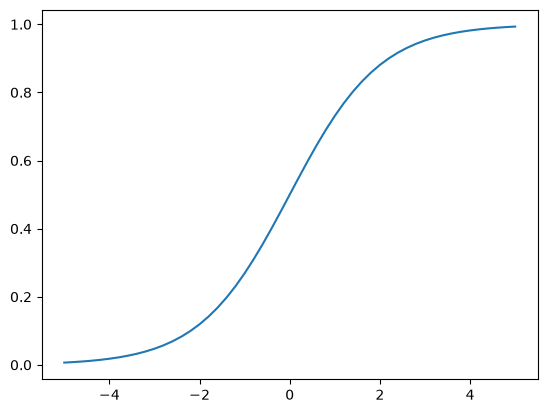

In [80]:
plt.plot(z, sigmoid(z))

#### Train logistic regression with scikit-learn

In [83]:
from sklearn.linear_model import LogisticRegression


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [86]:
model.coef_[0].round(3)

array([ 0.476, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.336,  0.317, -0.089,  0.004, -0.258,  0.142,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.059, -0.087, -0.032,  0.07 , -0.059,  0.142,
       -0.25 ,  0.216, -0.121, -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [87]:
model.intercept_[0].round(3)

np.float64(-0.109)

In [88]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [90]:
model.predict_proba(X_train)[:, 1]

array([0.09547508, 0.67941715, 0.63369753, ..., 0.53233201, 0.04238671,
       0.6987966 ], shape=(4225,))

In [91]:
y_pred = model.predict_proba(X_val)[:, 1]

In [92]:
y_pred

array([0.00896799, 0.20454216, 0.21215178, ..., 0.1363222 , 0.79995367,
       0.83758207], shape=(1409,))

In [94]:
churn_decision = (y_pred >= 0.5)

In [95]:
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [98]:
df_val[churn_decision].customerid 

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 312, dtype: str

In [99]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [100]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [101]:
(y_val == churn_decision.astype(int)).mean()

np.float64(0.8026969481902059)

In [102]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [103]:
df_pred

,probability,prediction,actual
0,0.008968,0,0
1,0.204542,0,0
2,0.212152,0,0
3,0.543024,1,1
4,0.213658,0,0
...,...,...,...
1404,0.313711,0,0
1405,0.039280,0,1
1406,0.136322,0,0
1407,0.799954,1,1


In [107]:
df_pred['correct'] = (df_pred['prediction'] == df_pred['actual']).astype(bool)

In [108]:
df_pred.correct.mean()

np.float64(0.8026969481902059)

In [109]:
df_pred.head(10)

,probability,prediction,actual,correct
0,0.008968,0,0,True
1,0.204542,0,0,True
2,0.212152,0,0,True
3,0.543024,1,1,True
4,0.213658,0,0,True
5,0.205212,0,0,True
6,0.027733,0,0,True
7,0.002967,0,0,True
8,0.582746,1,1,True
9,0.461626,0,1,False


#### Model Interpretation

In [111]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [114]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.476),
 'contract=one_year': np.float64(-0.175),
 'contract=two_year': np.float64(-0.408),
 'dependents=no': np.float64(-0.03),
 'dependents=yes': np.float64(-0.078),
 'deviceprotection=no': np.float64(0.063),
 'deviceprotection=no_internet_service': np.float64(-0.089),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.034),
 'gender=male': np.float64(-0.073),
 'internetservice=dsl': np.float64(-0.336),
 'internetservice=fiber_optic': np.float64(0.317),
 'internetservice=no': np.float64(-0.089),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.258),
 'multiplelines=no_phone_service': np.float64(0.142),
 'multiplelines=yes': np.float64(0.009),
 'onlinebackup=no': np.float64(0.063),
 'onlinebackup=no_internet_service': np.float64(-0.089),
 'onlinebackup=yes': np.float64(-0.081),
 'onlinesecurity=no': np.float64(0.266),
 'onlinesecurity=no_internet_service': np.float64(-0.089),
 'onlinesecurity=yes'

In [116]:
small = ['contract', 'tenure', 'monthlycharges']
df_train[small].head()

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10


In [117]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [118]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [119]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [120]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [121]:
X_train_small = dv_small.transform(dicts_train_small)

In [123]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [124]:
model_small.intercept_[0].round(3)

np.float64(-2.478)

In [125]:
model_small.coef_[0].round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [126]:
dict(zip(dv_small.get_feature_names_out(), model_small.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [127]:
sigmoid(-2.47 + 0.97 + 50 * 0.027 + 5 * -0.036)

np.float64(0.41824062315816374)

#### Using the model

In [137]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')
dicts_full_train = [{k: v for k, v in d.items() if k != 'customerid'} for d in dicts_full_train]

In [138]:
dicts_full_train

[{'paperlessbilling': 'no',
  'onlinebackup': 'no_internet_service',
  'gender': 'male',
  'streamingtv': 'no_internet_service',
  'streamingmovies': 'no_internet_service',
  'partner': 'yes',
  'internetservice': 'no',
  'dependents': 'yes',
  'onlinesecurity': 'no_internet_service',
  'seniorcitizen': 0,
  'techsupport': 'no_internet_service',
  'deviceprotection': 'no_internet_service',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'paymentmethod': 'mailed_check',
  'contract': 'two_year',
  'tenure': 12,
  'monthlycharges': 19.7,
  'totalcharges': 258.35},
 {'paperlessbilling': 'no',
  'onlinebackup': 'yes',
  'gender': 'female',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'partner': 'no',
  'internetservice': 'dsl',
  'dependents': 'no',
  'onlinesecurity': 'yes',
  'seniorcitizen': 0,
  'techsupport': 'yes',
  'deviceprotection': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'paymentmethod': 'credit_card_(automatic)',
  'contract': 'one_year',
  'tenur

In [139]:
dv = DictVectorizer(sparse=False)

In [140]:
X_full_train = dv.fit_transform(dicts_full_train)

In [141]:
y_full_train = df_full_train.churn.values

In [142]:
y_full_train

array([0, 1, 0, ..., 1, 1, 0], shape=(5634,))

In [146]:
model = LogisticRegression(max_iter=10000).fit(X_full_train, y_full_train)

In [147]:
model.n_iter_

array([2159], dtype=int32)

In [148]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
dicts_test = [{k: v for k, v in d.items() if k != 'customerid'} for d in dicts_test]

In [149]:
X_test = dv.transform(dicts_test)

In [152]:
y_pred = model.predict_proba(X_test)[:, 1]

In [156]:
churn_decision = (y_pred >= 0.5)

In [157]:
df_test[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
12,6168-wfvvf,female,1,no,no,3,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,70.30,235.50
30,6402-zfppi,female,1,no,no,25,yes,yes,fiber_optic,yes,yes,no,no,yes,yes,month-to-month,yes,mailed_check,102.80,2660.20
35,0362-zbzwj,male,0,no,no,36,yes,yes,fiber_optic,no,no,no,no,no,yes,month-to-month,yes,electronic_check,84.90,3067.20
37,4559-uwiht,male,0,yes,no,14,yes,yes,fiber_optic,no,yes,yes,no,no,no,month-to-month,yes,electronic_check,82.65,1185.00
42,3488-pgmqj,male,1,no,no,8,yes,no,fiber_optic,no,yes,no,no,no,no,month-to-month,yes,electronic_check,74.50,606.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1392,5134-ikday,female,0,yes,yes,1,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,69.80,69.80
1395,4910-aqffx,male,0,yes,yes,9,yes,yes,fiber_optic,no,no,yes,no,no,no,month-to-month,yes,bank_transfer_(automatic),79.35,661.25
1403,2215-zafgx,male,0,no,no,9,yes,yes,fiber_optic,no,no,no,no,yes,no,month-to-month,yes,electronic_check,85.50,791.70
1404,5130-iekqt,male,1,no,no,25,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,no,mailed_check,105.95,2655.25


In [159]:
(churn_decision.astype(int) == y_test).mean()

np.float64(0.8126330731014905)

In [160]:
df_predicted = pd.DataFrame()
df_predicted['customerid'] = df_test.customerid
df_predicted['probability'] = y_pred
df_predicted['model_churn_decision'] = churn_decision.astype(int)
df_predicted['churn_real'] = y_test 

In [161]:
df_predicted

,customerid,probability,model_churn_decision,churn_real
0,8879-zkjof,0.067556,0,0
1,0201-mibol,0.094933,0,0
2,1600-dilpe,0.334179,0,0
3,8601-qacrs,0.457632,0,1
4,7919-zodzz,0.217540,0,0
...,...,...,...,...
1404,5130-iekqt,0.525678,1,1
1405,4452-rohmo,0.029340,0,0
1406,6164-haqtx,0.005136,0,0
1407,3982-dqlus,0.203923,0,0


In [163]:
df_predicted[df_predicted.model_churn_decision != df_predicted.churn_real]

,customerid,probability,model_churn_decision,churn_real
3,8601-qacrs,0.457632,0,1
21,8623-tmrby,0.328178,0,1
37,4559-uwiht,0.609605,1,0
44,2897-dovnd,0.696262,1,0
51,4597-elfts,0.012066,0,1
...,...,...,...,...
1388,0617-aqnwt,0.011873,0,1
1391,4760-xohvn,0.203501,0,1
1393,4701-mljpn,0.162831,0,1
1394,3943-kdree,0.469571,0,1


In [164]:
customer = dicts_test[10]

In [166]:
X_small = dv.transform([customer])

In [168]:
model.predict_proba(X_small)

array([[0.5194488, 0.4805512]])

In [169]:
y_test[10]

np.int64(0)

In [170]:
customer = dicts_test[-1]

In [171]:
X_small = dv.transform([customer])
model.predict_proba(X_small)

array([[0.35981268, 0.64018732]])

In [172]:
y_test[-1]

np.int64(1)